<a href="https://colab.research.google.com/github/dimlish/TT-completion/blob/main/TT_Completion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Preparations

In [ ]:
!pip install ttax
!pip install jax

import jax
import ttax
from ttax.base_class import TT
import numpy as np
import jax.numpy as jnp
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import jax.tools.colab_tpu

     |████████████████████████████████| 183 kB 4.1 MB/s 
     |████████████████████████████████| 118 kB 49.3 MB/s 
     |████████████████████████████████| 57 kB 4.2 MB/s 
  Created wheel for ttax: filename=ttax-0.0.3-py3-none-any.whl size=24298 sha256=7ef3cf1e3f5338997c5f82ee15ad20842663d68d86f5b0edbc8e2164ae782814
  Stored in directory: /root/.cache/pip/wheels/45/fa/95/340e82541043dbc5eb0e21122509ab6530c7e3c3e4da029cb9
Successfully built ttax


In [ ]:
rng = jax.random.PRNGKey(1)
X = ttax.random_.tensor(rng, [4, 5, 6], tt_rank=6, dtype=jnp.float32)

a = ttax.random.tensor(rng, [2, 3, 4])
print(a[1, :, :])
print(a[:, 1, 1])

def f(x):
    return ttax.ops.flat_inner(x, x)

d = ttax.autodiff.grad(f)
jit_d = jax.jit(ttax.autodiff.grad(f))
jit_fused_d = jax.jit(ttax.fuse(ttax.autodiff.grad(f)))

TT-Tensor of shape (3, 4) and TT-ranks [1, 2, 1] with float32 elements.
TT-Tensor of shape (2,) and TT-ranks [1, 1] with float32 elements.


In [ ]:
%timeit d(X)

The slowest run took 49.78 times longer than the fastest. This could mean that an intermediate result is being cached.
1 loop, best of 5: 31.7 ms per loop


In [ ]:
%timeit jit_d(X)

The slowest run took 16713.73 times longer than the fastest. This could mean that an intermediate result is being cached.
1 loop, best of 5: 59.7 µs per loop


In [ ]:
%timeit jit_fused_d(X)

The slowest run took 17165.88 times longer than the fastest. This could mean that an intermediate result is being cached.
1 loop, best of 5: 58.1 µs per loop


In [ ]:
expected = 2*ttax.ops.full(X)
np.testing.assert_allclose(ttax.ops.full(d(X)), expected, rtol=1e-4)
np.testing.assert_allclose(ttax.ops.full(jit_d(X)), expected, rtol=1e-4)
np.testing.assert_allclose(ttax.ops.full(jit_fused_d(X)), expected, rtol=1e-4)

## CG

In [ ]:
def TensorCompletion(PA, P, r, retractor=ttax.decompositions.round, tol=1e-2, stag=1e-4, max_iter=50, armijo_tol=None, debug=False):
  """
     Returns optimal X for tensor completion problem with fixed TT rank using CG 

     Args:
      PA - target tensor (sampled)
      P - sampling operator (takes tensor with shape PA.shape;
                             returns TT)
      r - TT rank of X
      retractor - retraction function from tangent space to manifold of tensors with fixed TT rank r
      tol - relative residue tolerance
      stag - stagnation limit of relative error
      max_iter - maximum amount of iterations
      armijo_tol - tolerance for Armijo backtracking; None - disabled backtracking
      debug - print debug info
  """


  rng = jax.random.PRNGKey(1)
  X_prev = ttax.random_.tensor(rng, PA.shape, tt_rank=r)
  PA = PA * -1
  PA_norm = ttax.ops.flat_inner(PA, PA)
  PX = P(X_prev)
  res = PX + PA # Euclidean gradient (also residue) PX - PA
  dir_prev = ttax.autodiff.project(res, X_prev) # Riemann gradient
  Pd = dir_prev
  a = -1 * ttax.flat_inner(Pd, res) / ttax.flat_inner(Pd, Pd)
  X_cur = retractor(X_prev + a * dir_prev, r)   
  PX = P(X_cur)
  res = PX + PA
  rel_res = jnp.sqrt(ttax.ops.flat_inner(res, res)/PA_norm)
  norm_prev = ttax.ops.flat_inner(dir_prev, dir_prev)

  iter_num = 0

  while rel_res >= tol and iter_num < max_iter:
    dir_cur = ttax.autodiff.project(res, X_cur)

    norm_cur = ttax.ops.flat_inner(dir_cur, dir_cur)
    b = jnp.sqrt(norm_cur/norm_prev)

#    if b < stagnation:
#        return X_cur

    dir_cur += b * ttax.autodiff.project(res, X_cur)
    Pd = P(dir_cur)
    a = -1 * ttax.ops.flat_inner(Pd, res)/ttax.flat_inner(Pd, Pd)

    X_prev = X_cur


    if armijo_tol is not None:
      X_cur = retractor(X_prev + a * dir_cur, r)
      old_norm = ttax.ops.flat_inner(res, res)
      PX = P(X_cur)
      res = PX + PA
      new_norm = ttax.ops.flat_inner(res, res)
      while old_norm - new_norm <= -armijo_tol * ttax.ops.flat_inner(RG, dir_prev):
        a *= 0.5
        X_cur = retractor(X_prev + a * dir_cur, r)
        PX = P(X_cur)
        res = PX + PA
        new_norm = ttax.ops.flat_inner(res, res)
    else:
        X_cur = retractor(X_prev + a * dir_cur, r)
        PX = P(X_cur)
        res = PX + PA

    dir_prev = dir_cur
    prev_rel_res = rel_res
    rel_res = jnp.sqrt(ttax.ops.flat_inner(res, res) / PA_norm)
    norm_prev = norm_cur
    if jnp.abs(prev_rel_res - rel_res)/prev_rel_res < stag:
        if debug:
            print("stagnation")
        return X_prev

    iter_num += 1
    if debug:
        print(iter_num, rel_res)

  return X_cur

## TT-SVD

In [ ]:
def TTSVD(T, tol=0):
    """
      Returns TT decomposition of Tensor T via SVD of unfolding matrices

      Args:
        T - target tensor
        tol - tolerance for singular values of unfolding matrices

    """
    dim = len(T.shape)
    tt_rank = [1]
    tt_cores = []
    R = jnp.array(T, copy=True)

    for i in range(dim-1):
        R = R.reshape((T.shape[i] * tt_rank[i], -1)) # Remaining tensor
        U, S, VT = jnp.linalg.svd(R, full_matrices=False)

        S_len = 0
        while S[S_len] > tol * S[0] and S_len < S.size:
            S_len += 1
        if S_len == 0: # tol is too little
           S_len = 1

        U = U[:,:S_len]
        S = S[:S_len]
        VT = VT[:S_len]
      
        tt_rank.append(S_len)
        tt_cores.append(U.reshape((tt_rank[i], T.shape[i], tt_rank[i+1])))
        R = jnp.diag(S) @ VT

    tt_cores.append(R.reshape(tt_rank[-1], T.shape[dim-1], 1))
    return ttax.base_class.TT(tt_cores)

In [ ]:
A = jnp.asarray([[[1, 2, 3], [4, 5, 6]], [[2, 4, 6], [8, 10, 12]], [[3, 2, 1], [17, 13, 22]]])
#A = jnp.asarray([[[0, 0, 0], [0, 5, 0]], [[0, 0, 0], [0, 0, 0]]])
print(A)
B = TTSVD(A, 0.01)
print(ttax.ops.full_tt_tensor(B))

[[[ 1  2  3]
  [ 4  5  6]]

 [[ 2  4  6]
  [ 8 10 12]]

 [[ 3  2  1]
  [17 13 22]]]
[[[ 0.99999905  1.9999982   2.9999974 ]
  [ 3.9999983   4.9999986   5.999998  ]]

 [[ 1.9999977   3.999996    5.9999943 ]
  [ 7.999995    9.999995   11.999993  ]]

 [[ 2.9999914   1.9999963   0.99999034]
  [16.999994   12.999994   21.999989  ]]]


## Completion of $e^{-\|v\|}$

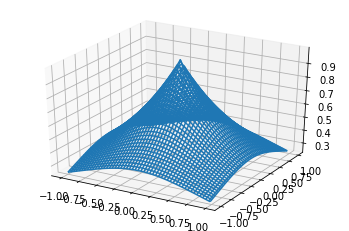

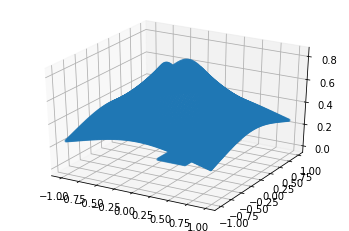

In [ ]:
start = -1
end = 1
step = 0.02
sing_rad = 0.2
ox, oy = jnp.meshgrid(jnp.arange(start, end, step), jnp.arange(start, end, step))
func_grid = jnp.exp(-jnp.sqrt(ox * ox + oy * oy))


fig1 = plt.figure()
ax = fig1.add_subplot(111, projection='3d')
ax.plot_wireframe(ox, oy, func_grid)


mid = round((end - start) / step / 2)
s_start = mid - round(sing_rad / step) # signularity must be cut down
s_end = mid + round(sing_rad / step)

no_sing_grid = jax.ops.index_update(func_grid, jax.ops.index[s_start:s_end,s_start:s_end], 0)
fig2 = plt.figure()
bx = fig2.add_subplot(111, projection='3d')
bx.scatter(ox, oy, no_sing_grid, marker='.')

In [ ]:
rng = jax.random.PRNGKey(41)
tt = ttax.random.tensor(rng, [2, 3, 4], tt_rank=2, batch_shape=(3, 3, 3,))
print(tt.batch_loc[1, 1, 1][1,1,0:2])

TT-Tensor of shape (2,) and TT-ranks [1, 1] with float32 elements.


## Samplers

In [ ]:
def GenerateSampler(key, shape, save_rate, sing_start, sing_end):
    """
        Args:
            key - jax PRNG key
            shape - shape of tensor
            save_rate - rate of elements not set to zero
            sing_start - starting index of singularity (will be cut out)
            sing_end - ending index of singularity
        Returns:
           SamplerFunc - sampler function for tensor completion
    """

    Sampler = jax.random.bernoulli(key, p=save_rate, shape=shape)
    Sampler = jax.ops.index_update(Sampler, jax.ops.index[sing_start:sing_end,sing_start:sing_end], 0)
    Sampler_TT = TTSVD(Sampler)
    def SamplerFunc(in_TT):
        return ttax.decompositions.round(Sampler_TT * in_TT)
    return SamplerFunc

In [ ]:
def GenerateSamplerM(key, shape, save_rate, sing_start, sing_end):
    """
        Args:
            key - jax PRNG key
            shape - shape of tensor
            save_rate - rate of elements not set to zero
            sing_start - starting index of singularity (will be cut out)
            sing_end - ending index of singularity
        Returns:
           SamplerFunc - sampler function for tensor completion
    """

    Sampler = jax.random.bernoulli(key, p=save_rate, shape=shape)

    Sampler = jax.ops.index_update(Sampler, jax.ops.index[sing_start:sing_end,sing_start:sing_end], 0)
    def SamplerFunc(in_TT):
        return TTSVD(Sampler * ttax.ops.full(in_TT))
    return SamplerFunc

In [ ]:
def GenerateSamplerControl(shape, sample_size, control_size, sing_start, sing_end):
    """
        Args:
            key - jax PRNG key
            shape - shape of tensor
            save_rate - rate of elements not set to zero
            sing_start - starting index of singularity (will be cut out)
            sing_end - ending index of singularity
        Returns:
           SamplerFunc - sampler function for tensor completion
    """
    rng = np.random.default_rng()
  
    len = shape[0] * shape[1]
    indices = np.zeros((len, 2), dtype=np.int32)
    for i in range(shape[0]):
        for j in range(shape[1]):
            indices[i + j * shape[0]] = [i, j]

    S_and_C = rng.choice(indices, size=(sample_size+control_size), replace=False)
    S = S_and_C[:sample_size]
    C = S_and_C[sample_size:]
    def SamplerFunc(in_TT):
        result = TTSVD(jnp.zeros(shape))
        for i, j in S:
            print(result.tt_ranks)
            print(in_TT[i:i+1,j:j+1].tt_ranks)
            result[i:i+1,j:j+1] = in_TT[i:i+1,j:j+1]
        return result

    def ControlFunc(in_TT):
        result = TTSVD(jnp.zeros(shape))
        for i, j in C:
            result[i:i+1,j:j+1] = in_TT[i:i+1,j:j+1]
        return result

    return SamplerFunc, ControlFunc

In [ ]:
def GenerateSamplerControlM(shape, sample_size, control_size, sing_start, sing_end):
    """
        Args:
            key - jax PRNG key
            shape - shape of tensor
            save_rate - rate of elements not set to zero
            sing_start - starting index of singularity (will be cut out)
            sing_end - ending index of singularity
        Returns:
           SamplerFunc - sampler function for tensor completion
    """
    rng = np.random.default_rng()
  
    len = shape[0] * shape[1]
    indices = np.zeros((len, 2), dtype=np.int32)
    for i in range(shape[0]):
        for j in range(shape[1]):
            indices[i + j * shape[0]] = [i, j]

    S_and_C = rng.choice(indices, size=(sample_size+control_size), replace=False)
    S = S_and_C[:sample_size]
    C = S_and_C[sample_size:]
    def SamplerFunc(in_TT):
        result = np.zeros(shape)
        for i, j in S:
            result[i][j] = in_TT.tt_cores[0][:,i] @ in_TT.tt_cores[1][:,j] 
        return TTSVD(result)

    def ControlFunc(in_TT):
        result = np.zeros(shape)
        for i, j in S:
            result[i][j] = in_TT.tt_cores[0][:,i] @ in_TT.tt_cores[1][:,j] 
        return TTSVD(result)

    return SamplerFunc, ControlFunc

In [ ]:
"""
size = func_grid.shape[0] * func_grid.shape[1]
sample_size = round(size * 0.1)
control_size = round(size * 0.02)
P, C = GenerateSamplerControlM(func_grid.shape, sample_size, control_size, s_start, s_end)

grid_TT = TTSVD(func_grid)
print(ttax.ops.flat_inner(grid_TT, grid_TT))
uncompleted = ttax.ops.full(P(grid_TT))
un_TT = P(grid_TT)
print(un_TT.tt_ranks)
#print(ttax.ops.flat_inner(un_TT, un_TT))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ox, oy, uncompleted, marker='.')
"""

"\nsize = func_grid.shape[0] * func_grid.shape[1]\nsample_size = round(size * 0.1)\ncontrol_size = round(size * 0.02)\nP, C = GenerateSamplerControlM(func_grid.shape, sample_size, control_size, s_start, s_end)\n\ngrid_TT = TTSVD(func_grid)\nprint(ttax.ops.flat_inner(grid_TT, grid_TT))\nuncompleted = ttax.ops.full(P(grid_TT))\nun_TT = P(grid_TT)\nprint(un_TT.tt_ranks)\n#print(ttax.ops.flat_inner(un_TT, un_TT))\n\nfig = plt.figure()\nax = fig.add_subplot(111, projection='3d')\nax.scatter(ox, oy, uncompleted, marker='.')\n"

2562.3403
[1, 100, 1]


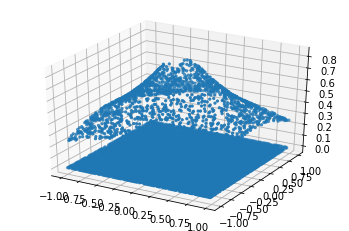

In [ ]:
rkey = jax.random.PRNGKey(2)
P = GenerateSamplerM(rkey, func_grid.shape, 0.2, s_start, s_end)

grid_TT = TTSVD(func_grid)
print(ttax.ops.flat_inner(grid_TT, grid_TT))
uncompleted = ttax.ops.full(P(grid_TT))
un_TT = P(grid_TT)
print(un_TT.tt_ranks)
#print(ttax.ops.flat_inner(un_TT, un_TT))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ox, oy, uncompleted, marker='.')

## TEST

In [ ]:
rkey = jax.random.PRNGKey(2)
P = GenerateSamplerM(rkey, func_grid.shape, 0.2, s_start, s_end)
result_TT = TensorCompletion(P(grid_TT), P, 5, debug=True)
result = ttax.ops.full(result_TT)


1 1.5927593
2 1.1350232
3 0.9651692
4 0.87168795
5 0.80310947
6 0.74453545
7 0.6904064
8 0.6378235
9 0.58615744
10 0.53521067
11 0.48608878
12 0.43985507
13 0.39766243
14 0.35985187
15 0.32654545
16 0.2973049
17 0.27180126
18 0.24952103
19 0.23012964
20 0.21322298
21 0.1985105
22 0.1856742
23 0.17446543
24 0.16464068
25 0.15599874
26 0.14835973
27 0.14157325
28 0.1355137
29 0.13007195
30 0.12516125
31 0.120705135
32 0.11664582
33 0.112926334
34 0.10950901
35 0.10635142
36 0.10342902
37 0.1007102
38 0.098177806
39 0.09580799
40 0.09358698
41 0.091498904
42 0.08953385
43 0.08767814
44 0.08592309
45 0.08425952
46 0.082683
47 0.08118222
48 0.07975493
49 0.0783938
50 0.077096194


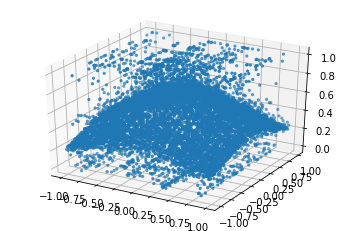

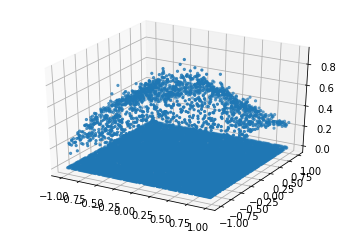

In [ ]:
result = np.array(result)
result[result>1] = 1
result[result<0] = 0

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ox, oy, result, marker='.')
fig2 = plt.figure()
ax = fig2.add_subplot(111, projection='3d')
ax.scatter(ox, oy, ttax.ops.full(P(result_TT)), marker='.')

In [ ]:
rng = jax.random.PRNGKey(5)
C = GenerateSamplerM(rng, func_grid.shape, 0.05, s_start, s_end)
CX = C(result_TT)
CA = -1 * C(grid_TT)
err = CX + CA
rel_err = jnp.sqrt(ttax.ops.flat_inner(err, err)/ttax.ops.flat_inner(CA, CA))
print(rel_err)

# Возможно высокая ошибка объясняется большим количеством выбросов

1.3789126


## Hyperspectral image

In [ ]:
import scipy.io
mat = scipy.io.loadmat('drive/MyDrive/ribeira1.mat')

(1017, 1340, 33)


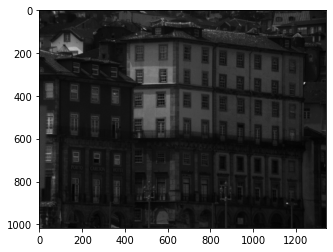

In [ ]:
orig_img = jnp.array(mat['reflectances'])
print(orig_img.shape)
plt.imshow(orig_img[:,:,2], cmap='gray')
plt.show()

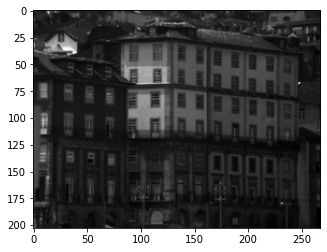

In [ ]:
shape=(203, 268, 33)
img = jax.image.resize(orig_img, shape, "cubic") # downsampling
plt.imshow(img[:,:,2], cmap='gray')
plt.show()

In [ ]:
def GenerateSamplerImg(key, shape, save_rate):
    """
        Args:
            key - jax PRNG key
            shape - shape of tensor
            save_rate - rate of elements not set to zero
            sing_start - starting index of singularity (will be cut out)
            sing_end - ending index of singularity
        Returns:
           SamplerFunc - sampler function for tensor completion
    """

    Sampler = jax.random.bernoulli(key, p=save_rate, shape=shape)
    def SamplerFunc(in_TT):
        return TTSVD(Sampler * ttax.ops.full(in_TT))
    return SamplerFunc

(203, 268, 33)


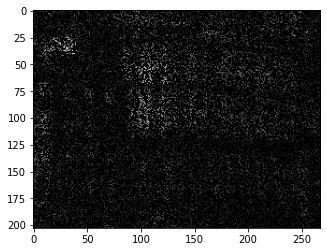

In [ ]:
rkey = jax.random.PRNGKey(14)
P_img = GenerateSamplerImg(rkey, img.shape, 0.2)
print(img.shape)
img_TT = TTSVD(img)
plt.imshow(ttax.ops.full(P_img(img_TT))[:,:,2], cmap='gray')
plt.show()

In [ ]:
result_TT = TensorCompletion(P_img(img_TT), P_img, 8, max_iter=25, debug=True)

1 3.1406758
2 1.3395096
3 1.0334176
4 0.92836803
5 0.4347413
6 0.38238364
7 0.33483416
8 0.2938976
9 0.26880178
10 0.25545073
11 0.24930237
12 0.24619038
13 0.24432021
14 0.24306598
15 0.24218848
16 0.24156259
17 0.24111277
18 0.24078417
19 0.24054186
20 0.24035926
21 0.24021804
22 0.24010648
23 0.24001606
24 0.23994027
25 0.23987737


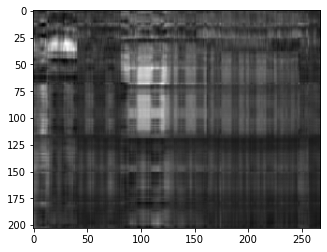

In [ ]:
result = ttax.ops.full(result_TT)
plt.imshow(result[:,:,2], cmap='gray')
plt.show()

## Hypersprectral image reshaped to hypercube

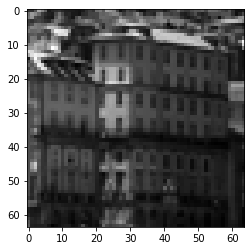

[4, 4, 4, 4, 4, 4, 4, 4]


In [ ]:
new_img = jax.image.resize(orig_img, (64, 64, 16), "cubic") # downsampling
plt.imshow(new_img[:,:,31], cmap='gray')
plt.show()

new_shape = []
for i in range(8):
    new_shape.append(4)
new_img = new_img.reshape(new_shape)
print(new_shape)

rkey = jax.random.PRNGKey(17)
new_P_img = GenerateSamplerImg(rkey, new_img.shape, 0.2)
new_img_TT = TTSVD(new_img)

In [ ]:
new_result_TT = TensorCompletion(new_P_img(new_img_TT), new_P_img, 3, max_iter=20, debug=True)
# работает медленнее
# возможно дело в неэффективном семплинге

1 2.1710188
2 1.2596498
3 1.1070454
4 1.0505477
5 1.0258352
6 1.0139015
7 1.007646
8 1.0041324
9 1.002049
10 1.0007458
11 0.99989456
12 0.9993123
13 0.99889696
14 0.9985877
15 0.9983487
16 0.9981567
17 0.9979982
18 0.99786294
19 0.9977452
20 0.9976401


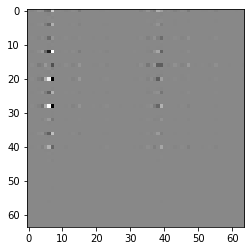

In [ ]:
new_result = ttax.ops.full(new_result_TT).reshape(64, 64, 16)
plt.imshow(new_result[:,:,2], cmap='gray')
plt.show()
# И то вообще не работает